In [22]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

def projection_simplex_sort(v, z=1):
    n_features = v.shape[0]
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - z
    ind = np.arange(n_features) + 1
    cond = u - cssv / ind > 0
    rho = ind[cond][-1]
    theta = cssv[cond][-1] / float(rho)
    w = np.maximum(v - theta, 0)

    return w

def duality_gap(A, x, y):

    return max(A.T @ x) - min(A @ y)

def energy(x, y, x_star, y_star, A, eta1, eta2):

    return sum((x - x_star) ** 2) / eta1 + sum((y - y_star) ** 2) / eta2 - sum((A @ (y - y_star)) * (x - x_star))

In [23]:
def run_altGDA(A, x0, y0, eta, T):

    x, y = x0, y0
    avg_x, avg_y = x, y
    altGDA_duality_gap = []

    for k in tqdm(range(T)):
        x = projection_simplex_sort(x - eta * A @ y)
        y = projection_simplex_sort(y + eta * A.T @ x)  # Alternating

        avg_x = avg_x + (x - avg_x) / (k + 1)
        avg_y = avg_y + (y - avg_y) / (k + 1)

        altGDA_duality_gap.append(duality_gap(A, avg_x, avg_y))

    return altGDA_duality_gap

In [24]:
def save_data(data_altGDA_s1, data_altGDA_s2, data_altGDA_s3, gen_type, n, m, T):
    if not os.path.exists('./data'):
        os.makedirs('./data')
    np.savez(f'./data/AltGDA_stepsize_choices_{gen_type}_{n}_{m}_{T}.npz', data_altGDA_s1=data_altGDA_s1,
             data_altGDA_s2=data_altGDA_s2, data_altGDA_s3=data_altGDA_s3)

In [25]:
n, m = 30, 60
list_gen_type = ['uniform', 'randint', 'normal', 'binary', 'exponential', 'lognormal']
RANDOM_SEED = 42

T = int(1e6)

for gen_type in list_gen_type:

    np.random.seed(RANDOM_SEED)

    if gen_type == 'uniform':
        A = np.random.rand(n, m)
    elif gen_type == 'randint': 
        A = np.random.randint(-10, 11, size=(n, m))
    elif gen_type == 'normal':
        A = np.random.randn(n, m)
    elif gen_type == 'binary':
        A = np.random.choice([0, 1], p=[0.8, 0.2], size=(n, m))
    elif gen_type == 'exponential':
        A = np.random.exponential(size=(n, m))
    elif gen_type == 'lognormal':
        A = np.random.lognormal(size=(n, m))
    else: 
        raise ValueError('Unknown gen_type')

    data_altGDA_s1 = {}
    data_altGDA_s2 = {}
    data_altGDA_s3 = {}
    for i in range(10): 
        np.random.seed(i)
        x0 = np.random.rand(n)
        x0 = x0 / sum(x0)
        y0 = np.random.rand(m)
        y0 = y0 / sum(y0)
        
        print(f'Running experiment for gen_type={gen_type}, n={n}, m={m}, T={T}, seed={i}')
        data_altGDA_s1[i] = run_altGDA(A, x0, y0, 0.1, T)
        data_altGDA_s2[i] = run_altGDA(A, x0, y0, 0.01, T)
        data_altGDA_s3[i] = run_altGDA(A, x0, y0, 0.001, T)
        
    save_data(data_altGDA_s1, data_altGDA_s2, data_altGDA_s3, gen_type, n, m, T)

Running experiment for gen_type=uniform, n=30, m=60, T=1000000, seed=0


100%|██████████| 1000000/1000000 [00:49<00:00, 20324.87it/s]


Running experiment for gen_type=uniform, n=30, m=60, T=1000000, seed=1


100%|██████████| 1000000/1000000 [00:52<00:00, 18902.57it/s]


Running experiment for gen_type=uniform, n=30, m=60, T=1000000, seed=2


...

100%|██████████| 1000000/1000000 [00:55<00:00, 18016.71it/s]


Running experiment for gen_type=randint, n=30, m=60, T=1000000, seed=8


100%|██████████| 1000000/1000000 [00:55<00:00, 18021.03it/s]


Running experiment for gen_type=randint, n=30, m=60, T=1000000, seed=9


100%|██████████| 1000000/1000000 [00:55<00:00, 18104.48it/s]


In [ ]:
# Load data and plot figures
for gen_type in list_gen_type:
    
    data = np.load(f'./data/AltGDA_stepsize_choices_{gen_type}_{n}_{m}_{T}.npz', allow_pickle=True)
    data_altGDA_s1 = data['data_altGDA_s1']
    data_altGDA_s2 = data['data_altGDA_s2']
    data_altGDA_s3 = data['data_altGDA_s3']
    
    mean_altGDA_s1 = []
    std_altGDA_s1 = []
    mean_altGDA_s2 = []
    std_altGDA_s2 = []
    mean_altGDA_s3 = []
    std_altGDA_s3 = []
    for i in tqdm(range(T)): 
        lst = []
        for key in data_altGDA_s1.item().keys():
            lst.append(data_altGDA_s1.item()[key][i])
        mean_altGDA_s1.append(np.mean(lst))
        std_altGDA_s1.append(np.std(lst))

        lst = []
        for key in data_altGDA_s2.item().keys():
            lst.append(data_altGDA_s2.item()[key][i])
        mean_altGDA_s2.append(np.mean(lst))
        std_altGDA_s2.append(np.std(lst))

        lst = []
        for key in data_altGDA_s3.item().keys():
            lst.append(data_altGDA_s3.item()[key][i])
        mean_altGDA_s3.append(np.mean(lst))
        std_altGDA_s3.append(np.std(lst))

    # Save the statistics
    if not os.path.exists('./data'):
        os.makedirs('./data')
    np.savez(f'./data/AltGDA_stepsize_choices_{gen_type}_{n}_{m}_{T}.npz', mean_altGDA_s1=mean_altGDA_s1, std_altGDA_s1=std_altGDA_s1,
                mean_altGDA_s2=mean_altGDA_s2, std_altGDA_s2=std_altGDA_s2, mean_altGDA_s3=mean_altGDA_s3, std_altGDA_s3=std_altGDA_s3)

100%|██████████| 1000000/1000000 [01:17<00:00, 12929.02it/s]


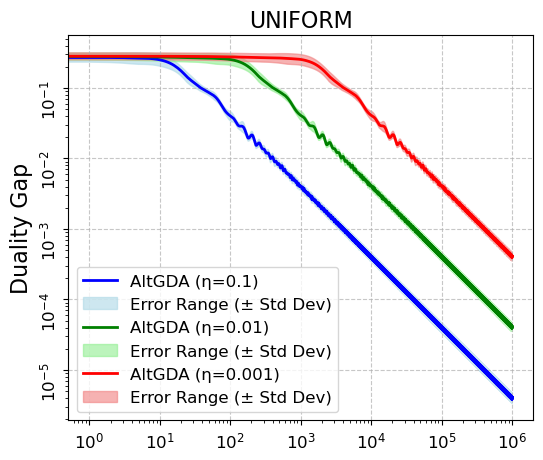

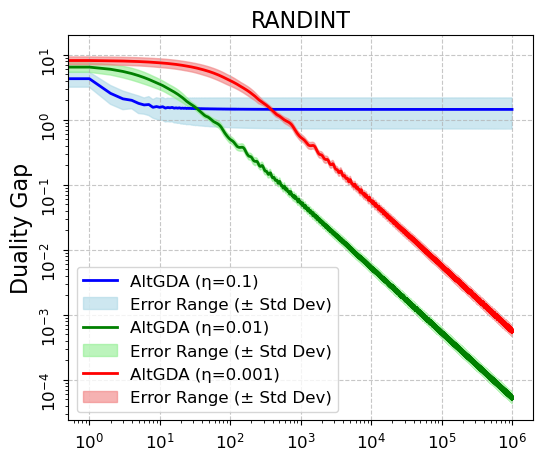

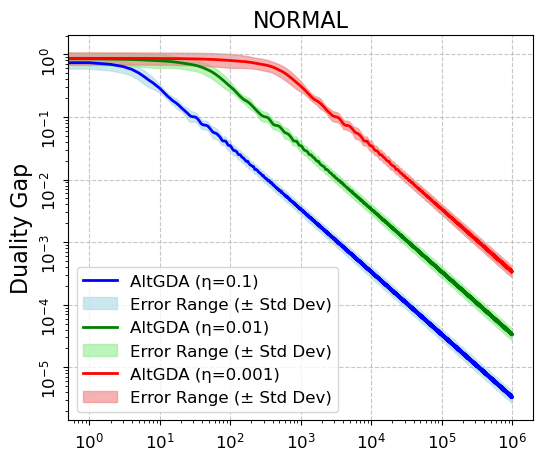

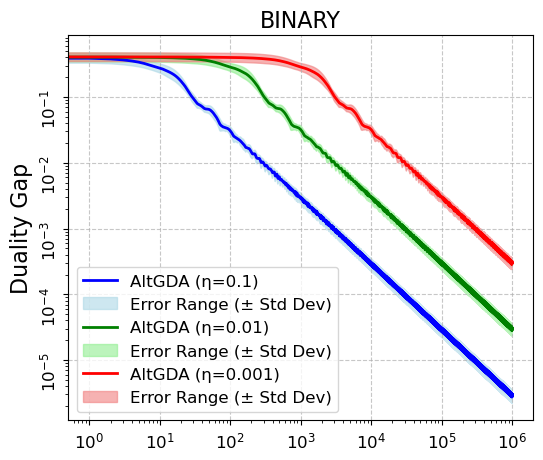

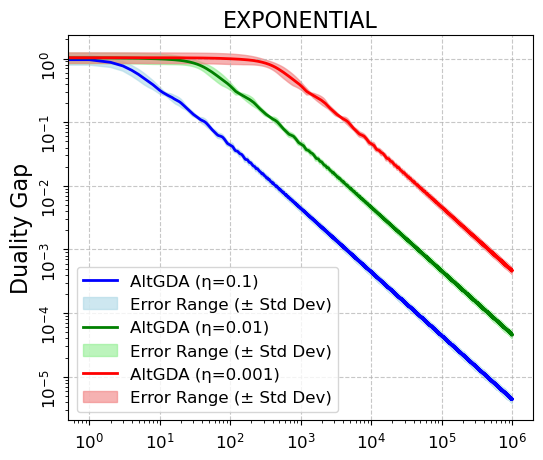

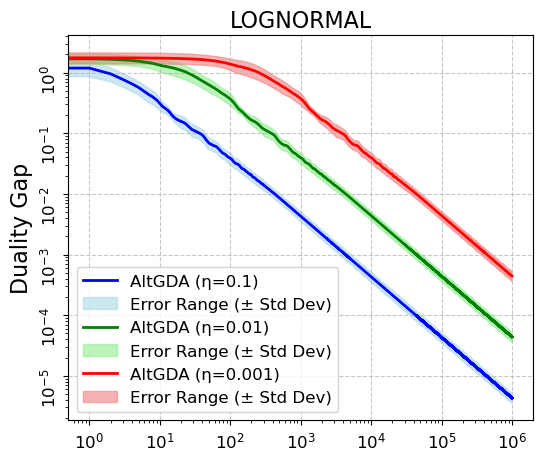

In [ ]:
list_gen_type = ['uniform', 'randint', 'normal', 'binary', 'exponential', 'lognormal']

for gen_type in list_gen_type:
    # Load statistics
    data = np.load(f'./data/AltGDA_stepsize_choices_{gen_type}_{n}_{m}_{T}.npz', allow_pickle=True)
    mean_altGDA_s1 = data['mean_altGDA_s1']
    std_altGDA_s1 = data['std_altGDA_s1']
    mean_altGDA_s2 = data['mean_altGDA_s2']
    std_altGDA_s2 = data['std_altGDA_s2']
    mean_altGDA_s3 = data['mean_altGDA_s3']
    std_altGDA_s3 = data['std_altGDA_s3']

    # Create the plot
    plt.figure(figsize=(6, 5)) # Adjust figure size for better aesthetics
    # plt.style.use('seaborn-v0_8-darkgrid') # Apply a clean style

    mean_altGDA_s1 = np.array(mean_altGDA_s1)
    std_altGDA_s1 = np.array(std_altGDA_s1)
    mean_altGDA_s2 = np.array(mean_altGDA_s2)
    std_altGDA_s2 = np.array(std_altGDA_s2)
    mean_altGDA_s3 = np.array(mean_altGDA_s3)
    std_altGDA_s3 = np.array(std_altGDA_s3)

    # Plot AltGDA results
    plt.loglog(list(range(T)), mean_altGDA_s1, color='blue', linewidth=2, label='AltGDA (η=0.1)')
    # Add the error range using fill_between
    plt.fill_between(list(range(T)), mean_altGDA_s1 - std_altGDA_s1, mean_altGDA_s1 + std_altGDA_s1, color='lightblue', alpha=0.6, label='Error Range (± Std Dev)')

    plt.loglog(list(range(T)), mean_altGDA_s2, color='green', linewidth=2, label='AltGDA (η=0.01)')
    # Add the error range using fill_between
    plt.fill_between(list(range(T)), mean_altGDA_s2 - std_altGDA_s2, mean_altGDA_s2 + std_altGDA_s2, color='lightgreen', alpha=0.6, label='Error Range (± Std Dev)')

    plt.loglog(list(range(T)), mean_altGDA_s3, color='red', linewidth=2, label='AltGDA (η=0.001)')
    # Add the error range using fill_between
    plt.fill_between(list(range(T)), mean_altGDA_s3 - std_altGDA_s3, mean_altGDA_s3 + std_altGDA_s3, color='lightcoral', alpha=0.6, label='Error Range (± Std Dev)')

    # Uppercase a string
    def upper(s):
        return ''.join([c.upper() for c in s])

    # Enhance the plot
    plt.xlabel('')
    plt.xticks(fontsize=12)
    plt.ylabel('Duality Gap', fontsize=16)
    plt.yticks(fontsize=12, rotation=90)
    plt.title(f'{upper(gen_type)}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Save the plot
    if not os.path.exists('./figures'):
        os.makedirs('./figures')
    plt.savefig(f'./figures/AltGDA_stepsize_choices_{gen_type}_{n}_{m}_{T}.png', bbox_inches='tight', dpi=300)